##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from svipy.normflow import identityTimeEmbedding, fourierTimeEmbedding, scalarConditionedNetworkMLP, rademacherProbe
from svipy.normflow import continuousNormFlow, timeConditionedField, normFlowPosterior

from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


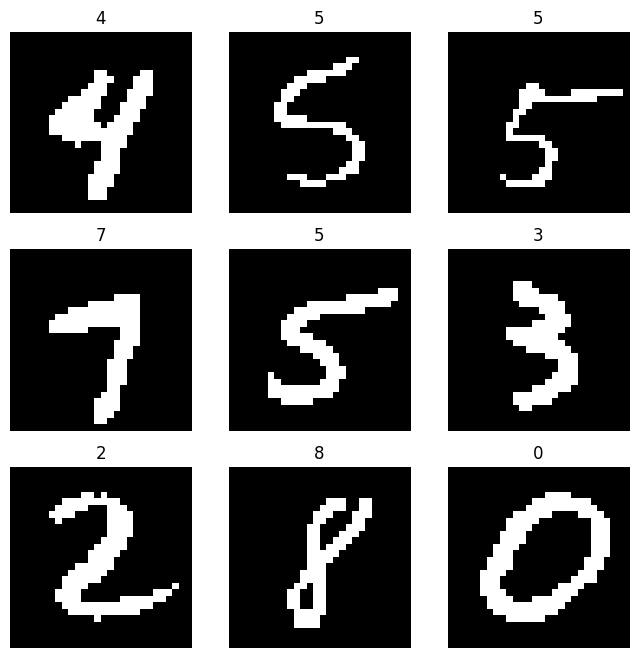

In [4]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


##### VAEs with norm flows

In [6]:
class sumBceDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

###### Continuous normalized flows

In [7]:
in_dims = 28 * 28
hid_dims = 8

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 256),
                        nn.ReLU(),
                        nn.Linear(256, 256),
                        nn.ReLU(),
                        nn.Linear(256, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 256),
                        nn.ReLU(),
                        nn.Linear(256, 256),
                        nn.ReLU(),
                        nn.Linear(256, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

t_dims = 1
embed = identityTimeEmbedding()
tcn = scalarConditionedNetworkMLP(dims = [hid_dims, 64, 64], t_dim=t_dims, activation=torch.nn.Tanh())
sampler = rademacherProbe

tcf = timeConditionedField(tcn, embed, sampler)
post = normFlowPosterior(continuousNormFlow(tcf, direction='generate', odeMethod='dopri5'))
model_vae_cnf = variationalAutoencoder(encoder, decoder, posterior=post).to(device)

In [8]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_cnf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [9]:
%%time 
model_vae_cnf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_cnf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------


D:\Anaconda3\envs\py312\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


totalLoss: 182.534409 reconLoss: 188.324020 klLoss: -5.789606 fldj: 5.898226[12800/60000]
totalLoss: 146.750748 reconLoss: 166.182220 klLoss: -19.431475 fldj: 18.030539[25600/60000]
totalLoss: 113.645645 reconLoss: 162.465790 klLoss: -48.820141 fldj: 50.328903[38400/60000]
totalLoss: 103.052330 reconLoss: 146.339905 klLoss: -43.287575 fldj: 50.216572[51200/60000]
Validation Error: 117.486325
Epoch 2
-------------------------------
totalLoss: 119.877800 reconLoss: 133.443848 klLoss: -13.566048 fldj: 28.928963[12800/60000]
totalLoss: 124.919754 reconLoss: 130.916473 klLoss: -5.996721 fldj: 28.703352[25600/60000]
totalLoss: 120.386383 reconLoss: 128.843140 klLoss: -8.456753 fldj: 24.562176[38400/60000]
totalLoss: 127.964775 reconLoss: 124.030602 klLoss: 3.934171 fldj: 23.247641[51200/60000]
Validation Error: 119.037608
Epoch 3
-------------------------------
totalLoss: 118.905540 reconLoss: 118.740082 klLoss: 0.165459 fldj: 19.430218[12800/60000]
totalLoss: 120.493324 reconLoss: 109.98788

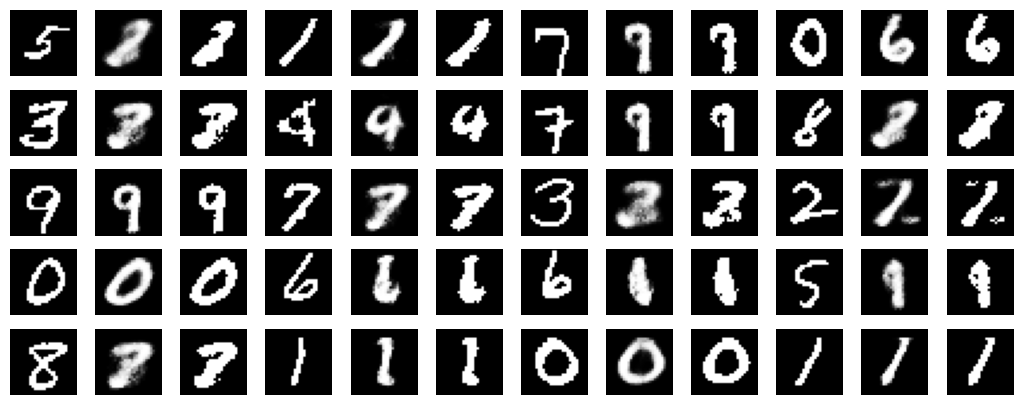

In [12]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_cnf.eval()

idxs = []

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        idxs.append(sidx)
        
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_cnf.deterministicRecon(trainImageData[sidx].unsqueeze(0).to(device))
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [12]:
activeUnits(model_vae_maf, trainImageData)

dim 0: Var_x[mu] = 10.621753  (active)
dim 1: Var_x[mu] = 17.017323  (active)
dim 2: Var_x[mu] = 19.876116  (active)
dim 3: Var_x[mu] = 15.486300  (active)
dim 4: Var_x[mu] = 9.418876  (active)
dim 5: Var_x[mu] = 29.662304  (active)
dim 6: Var_x[mu] = 28.533108  (active)
dim 7: Var_x[mu] = 17.105146  (active)
dim 8: Var_x[mu] = 14.126481  (active)
dim 9: Var_x[mu] = 11.447592  (active)
dim 10: Var_x[mu] = 17.320679  (active)
dim 11: Var_x[mu] = 20.871670  (active)
dim 12: Var_x[mu] = 9.943270  (active)
dim 13: Var_x[mu] = 13.301267  (active)
dim 14: Var_x[mu] = 21.935572  (active)
dim 15: Var_x[mu] = 14.695738  (active)
16/16 active units (threshold=0.01)


tensor([10.6218, 17.0173, 19.8761, 15.4863,  9.4189, 29.6623, 28.5331, 17.1051,
        14.1265, 11.4476, 17.3207, 20.8717,  9.9433, 13.3013, 21.9356, 14.6957])

In [13]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)


posterior = normFlowPosterior(normFlowSequential(OrderedDict([('iaf1', inverseAutoRegressiveFlow([16, 256, 256])),
                                                              ('iaf2', inverseAutoRegressiveFlow([16, 256, 256])),
                                                              ('iaf3', inverseAutoRegressiveFlow([16, 256, 256]))
                                                             ])), hid_dims)

model_vae_iaf = variationalAutoencoder(encoder, decoder, posterior=posterior).to(device)

In [14]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_iaf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [15]:
%%time 
model_vae_iaf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_iaf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 206.504257 reconLoss: 202.420425 klLoss: 4.083837[12800/60000]
totalLoss: 195.400833 reconLoss: 191.696930 klLoss: 3.703905[25600/60000]
totalLoss: 196.653473 reconLoss: 192.725586 klLoss: 3.927886[38400/60000]
totalLoss: 178.665771 reconLoss: 173.626816 klLoss: 5.038953[51200/60000]
Validation Error: 173.521379
Epoch 2
-------------------------------
totalLoss: 166.705444 reconLoss: 157.916107 klLoss: 8.789339[12800/60000]
totalLoss: 156.874084 reconLoss: 146.489624 klLoss: 10.384467[25600/60000]
totalLoss: 140.551544 reconLoss: 130.466812 klLoss: 10.084735[38400/60000]
totalLoss: 146.471786 reconLoss: 135.519714 klLoss: 10.952076[51200/60000]
Validation Error: 141.464813
Epoch 3
-------------------------------
totalLoss: 137.648361 reconLoss: 125.829041 klLoss: 11.819320[12800/60000]
totalLoss: 140.180740 reconLoss: 128.341614 klLoss: 11.839126[25600/60000]
totalLoss: 138.254211 reconLoss: 125.727875 klLoss: 12.526339[38400/60000]
to

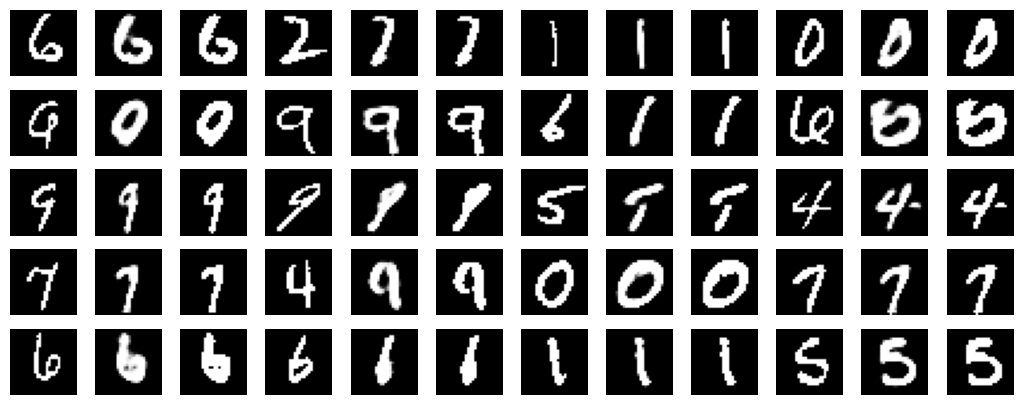

In [16]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_iaf.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = idxs[i] # torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_iaf.decode(model_vae_iaf.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [17]:
activeUnits(model_vae_iaf, trainImageData)

dim 0: Var_x[mu] = 8.967602  (active)
dim 1: Var_x[mu] = 15.432077  (active)
dim 2: Var_x[mu] = 17.758986  (active)
dim 3: Var_x[mu] = 3.644516  (active)
dim 4: Var_x[mu] = 4.592585  (active)
dim 5: Var_x[mu] = 1.887614  (active)
dim 6: Var_x[mu] = 5.116058  (active)
dim 7: Var_x[mu] = 7.055691  (active)
dim 8: Var_x[mu] = 7.962940  (active)
dim 9: Var_x[mu] = 6.730818  (active)
dim 10: Var_x[mu] = 2.135092  (active)
dim 11: Var_x[mu] = 8.303508  (active)
dim 12: Var_x[mu] = 7.101102  (active)
dim 13: Var_x[mu] = 9.903687  (active)
dim 14: Var_x[mu] = 7.316468  (active)
dim 15: Var_x[mu] = 6.269256  (active)
16/16 active units (threshold=0.01)


tensor([ 8.9676, 15.4321, 17.7590,  3.6445,  4.5926,  1.8876,  5.1161,  7.0557,
         7.9629,  6.7308,  2.1351,  8.3035,  7.1011,  9.9037,  7.3165,  6.2693])